# Train a LSTM RNN Model over out timeseries data


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay, average_precision_score, PrecisionRecallDisplay, accuracy_score, f1_score, average_precision_score


import kineticstoolkit as ktk

import pickle
import json
from typing import Tuple

from tensorflow import keras
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import layers as L, models as M, Input, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

from core.matlab_data_loader import MatlabDataLoader
from core.processing import preprocess_features
from core.timeseries import plot_compare_features, plot_all_features_overlay, bilateral_to_unilateral, split_unilateral


from pathlib import Path
import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



## Notebook configuration

- **SAVE_MODEL**  
  - `True`: Will run and save this iteration of the model.  
  - `False`: Will load the model from the results folder.

- **SAVE_DATA**  
  - `True`: Will save the train, test, and validation sets as npz files.  
  - `False`: Will load the data from the results folder.

- **MODEL_NAME**  
  - The name of the model.

- **MODEL_RESULTS_FOLDER**  
  - The folder where the model results will be saved.

In [2]:
MODEL_NAME = "unilateral_stance_bilstm"
MODEL_RESULTS_FOLDER = Path(c.RICKD_MODELS_FOLDER)/ "deep_learning" / MODEL_NAME
MODEL_RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Model results folder: {MODEL_RESULTS_FOLDER}")

Model results folder: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm


In [3]:
SAVE_MODEL = True
SAVE_DATA = False

print(f"SAVE_MODEL: {SAVE_MODEL}")
print(f"SAVE_DATA: {SAVE_DATA}")

SAVE_MODEL: True
SAVE_DATA: False


## Load Input Data

In [4]:
timeseries_folder = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(timeseries_folder / 'timeseries_matrix.npy')
with open(timeseries_folder / 'timeseries_channels.json', 'r') as f:
    channels = json.load(f)
with open(timeseries_folder / 'timeseries_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 48)
Number of channels:  48
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z


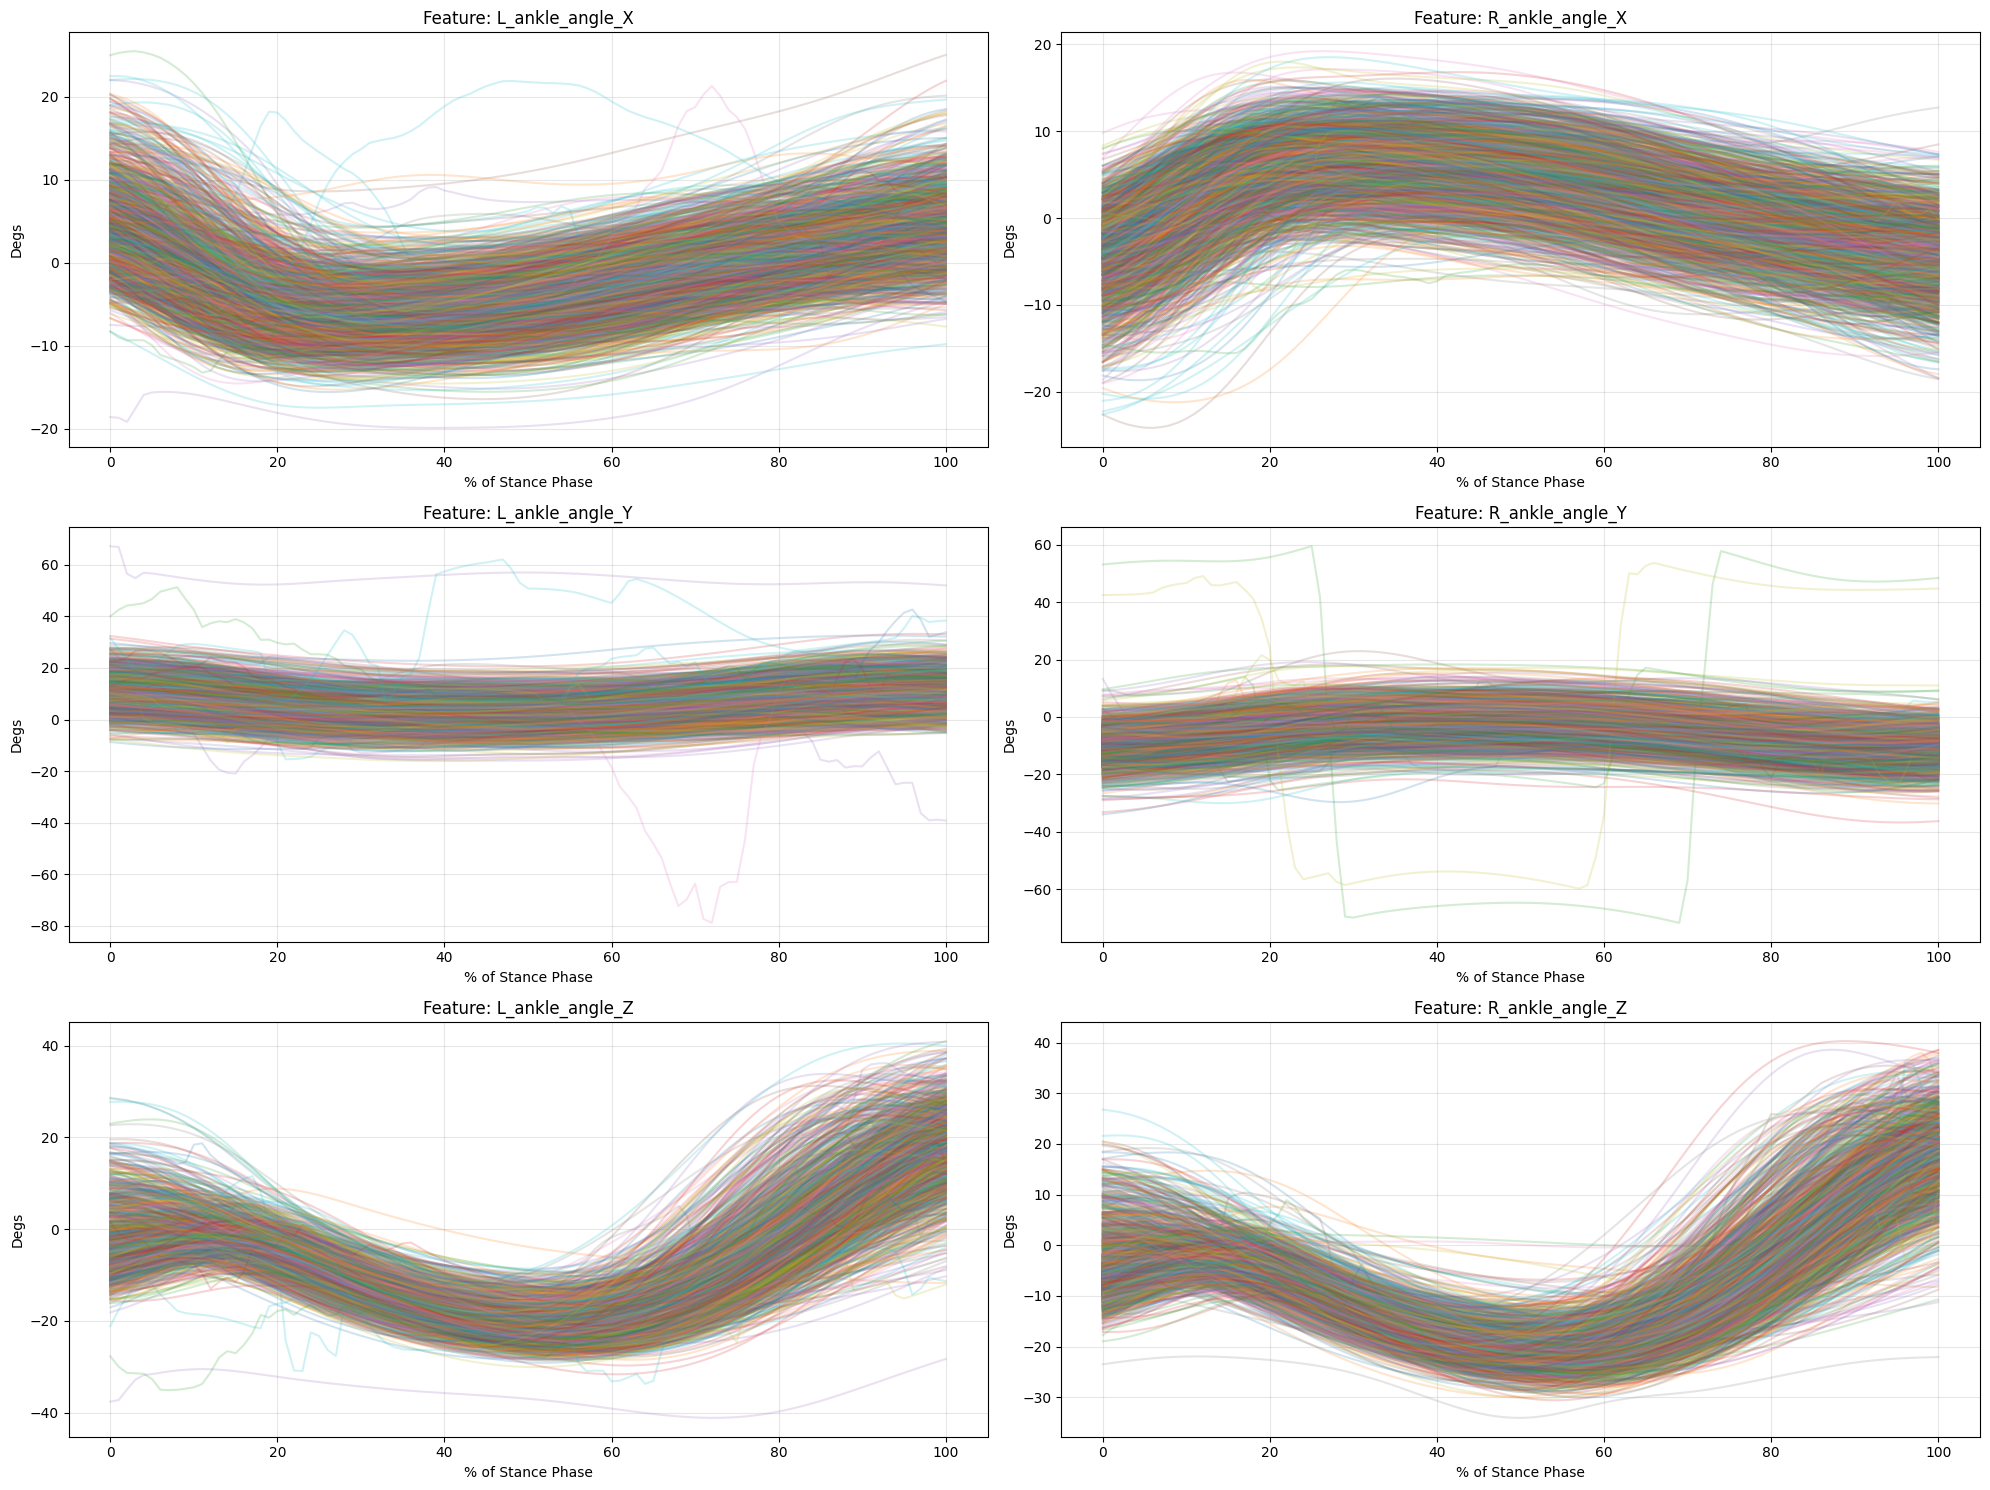

In [5]:
plot_all_features_overlay(
    X_ts=all_sessions_matrix,
    channels=channels,
    features=["L_ankle_angle_X", "R_ankle_angle_X", "L_ankle_angle_Y", "R_ankle_angle_Y", "L_ankle_angle_Z", "R_ankle_angle_Z"],
    plots_per_row=2,
    y_label="Degs"
)

In [6]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["age", "Height", "Weight", "Gender", "DominantLeg", "speed_r"]
metadata = session_data[metadata_columns]
complete_metadata = metadata.dropna()

num_complete_rows = complete_metadata.shape[0]
print(f"\nNumber of rows with a value for all metadata columns: {num_complete_rows}")
complete_metadata.info(verbose=True)



Number of rows with a value for all metadata columns: 1476
<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 100560_20120717T103748 to 201099_20150414T092041
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1476 non-null   float64
 1   Height       1476 non-null   float64
 2   Weight       1476 non-null   float64
 3   Gender       1476 non-null   object 
 4   DominantLeg  1476 non-null   object 
 5   speed_r      1476 non-null   float64
dtypes: float64(4), object(2)
memory usage: 80.7+ KB


In [7]:
# Compare valid_session_ids against sessions with complete metadata
session_ids = set(session_data.index.astype(str))
valid_ids = set(map(str, valid_session_ids))
intersection_ids = valid_ids & session_ids
complete_ids = set(complete_metadata.index.astype(str))
complete_intersection_ids = complete_ids & valid_ids

print(f"Number of sessions: {len(session_ids)}")
print(f"Number of time-series sessions: {len(valid_ids)}")
print(f"Number of sessions with complete metadata: {len(complete_ids)}")
print(f"Number of sessions present both in metadata and time-series: {len(intersection_ids)}")
print(f"Number of sessions with complete metadata and present in time-series: {len(complete_intersection_ids)}")
print(f"We loose {(1-(len(complete_intersection_ids) / len(valid_ids)))*100:.2f}% of the data due to missing metadata.")

Number of sessions: 1832
Number of time-series sessions: 1813
Number of sessions with complete metadata: 1476
Number of sessions present both in metadata and time-series: 1812
Number of sessions with complete metadata and present in time-series: 1456
We loose 19.69% of the data due to missing metadata.


In [8]:
metadata_common = complete_metadata.loc[list(complete_intersection_ids)]
filtered_indices = [i for i, sid in enumerate(valid_session_ids) if sid in complete_intersection_ids]

sessions_matrix_common = all_sessions_matrix[filtered_indices]
is_injured_common = session_data.loc[list(complete_intersection_ids), 'is_injured']
subject_id_common = session_data.loc[list(complete_intersection_ids), 'sub_id']


In [9]:
# N = 1456 -- Sessions with complete metadata and present in time-series.
X_ts: np.ndarray = sessions_matrix_common  #  (N, 101, 54)
y: pd.Series = is_injured_common  # (N,)
subject_id: pd.Series = subject_id_common  # (N,)

## Preprocessing of input data
- Scale with Z-Score & one-hot encode categorical cols
- Split data into train, validation and test sets

In [10]:
# Handle metadata preprocessing (one-hot encoding for categorical variables)
print("Preprocessing of Metadata")
print("="*50)
print("Original metadata columns:", metadata_common.columns.tolist())
print("Original metadata shape:", metadata_common.shape)

# Scale with Z-Score & one-hot encode categorical cols
X_meta_scaled_df, scaler_meta = preprocess_features(metadata_common, y, feature_categorical_columns=['Gender', 'DominantLeg'], return_scaler=True)
X_meta_scaled = X_meta_scaled_df.values.astype(np.float32)
meta_feature_names = X_meta_scaled_df.columns.tolist()

print(f"Final metadata shape: {X_meta_scaled.shape}")
print(f"Feature names: {meta_feature_names}")


Preprocessing of Metadata
Original metadata columns: ['age', 'Height', 'Weight', 'Gender', 'DominantLeg', 'speed_r']
Original metadata shape: (1456, 6)
Final metadata shape: (1456, 8)
Feature names: ['age', 'Height', 'Weight', 'speed_r', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']


In [11]:
# Step 1: Data Exploration and Preprocessing
print("Data overview")
print("="*50)
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Metadata shape: {X_meta_scaled.shape}")  # (N, metadata_features)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")
print(f"Missing values in metadata: {np.isnan(X_meta_scaled).sum()}")


Data overview
Timeseries shape: (1456, 101, 48)
Metadata shape: (1456, 8)
Labels shape: (1456,)
Subject IDs shape: (1456,)

Class distribution:
  Class 0: 397 samples (27.3%)
  Class 1: 1059 samples (72.7%)

Missing values in timeseries: 0
Missing values in metadata: 0


In [12]:
print("Preprocessing of Timeseries")
print("="*50)

print(f"Timeseries stats:")
print(f"  Min: {X_ts.min():.3f}, Max: {X_ts.max():.3f}")
print(f"  Mean: {X_ts.mean():.3f}, Std: {X_ts.std():.3f}")

# Reshape for scaling: (N*101, 48) -> scale -> reshape back to (N, 101, 48)
N, T, C = X_ts.shape
X_ts_reshaped = X_ts.reshape(-1, C)
scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts_reshaped).reshape(N, T, C).astype(np.float32)

print("")
print(f"Timeseries scaled stats:")
print(f"  Min: {X_ts_scaled.min():.3f}, Max: {X_ts_scaled.max():.3f}")
print(f"  Mean: {X_ts_scaled.mean():.3f}, Std: {X_ts_scaled.std():.3f}")


Preprocessing of Timeseries
Timeseries stats:
  Min: -11442.526, Max: 6956.552
  Mean: -0.929, Std: 113.039

Timeseries scaled stats:
  Min: -99.506, Max: 67.621
  Mean: -0.000, Std: 1.000


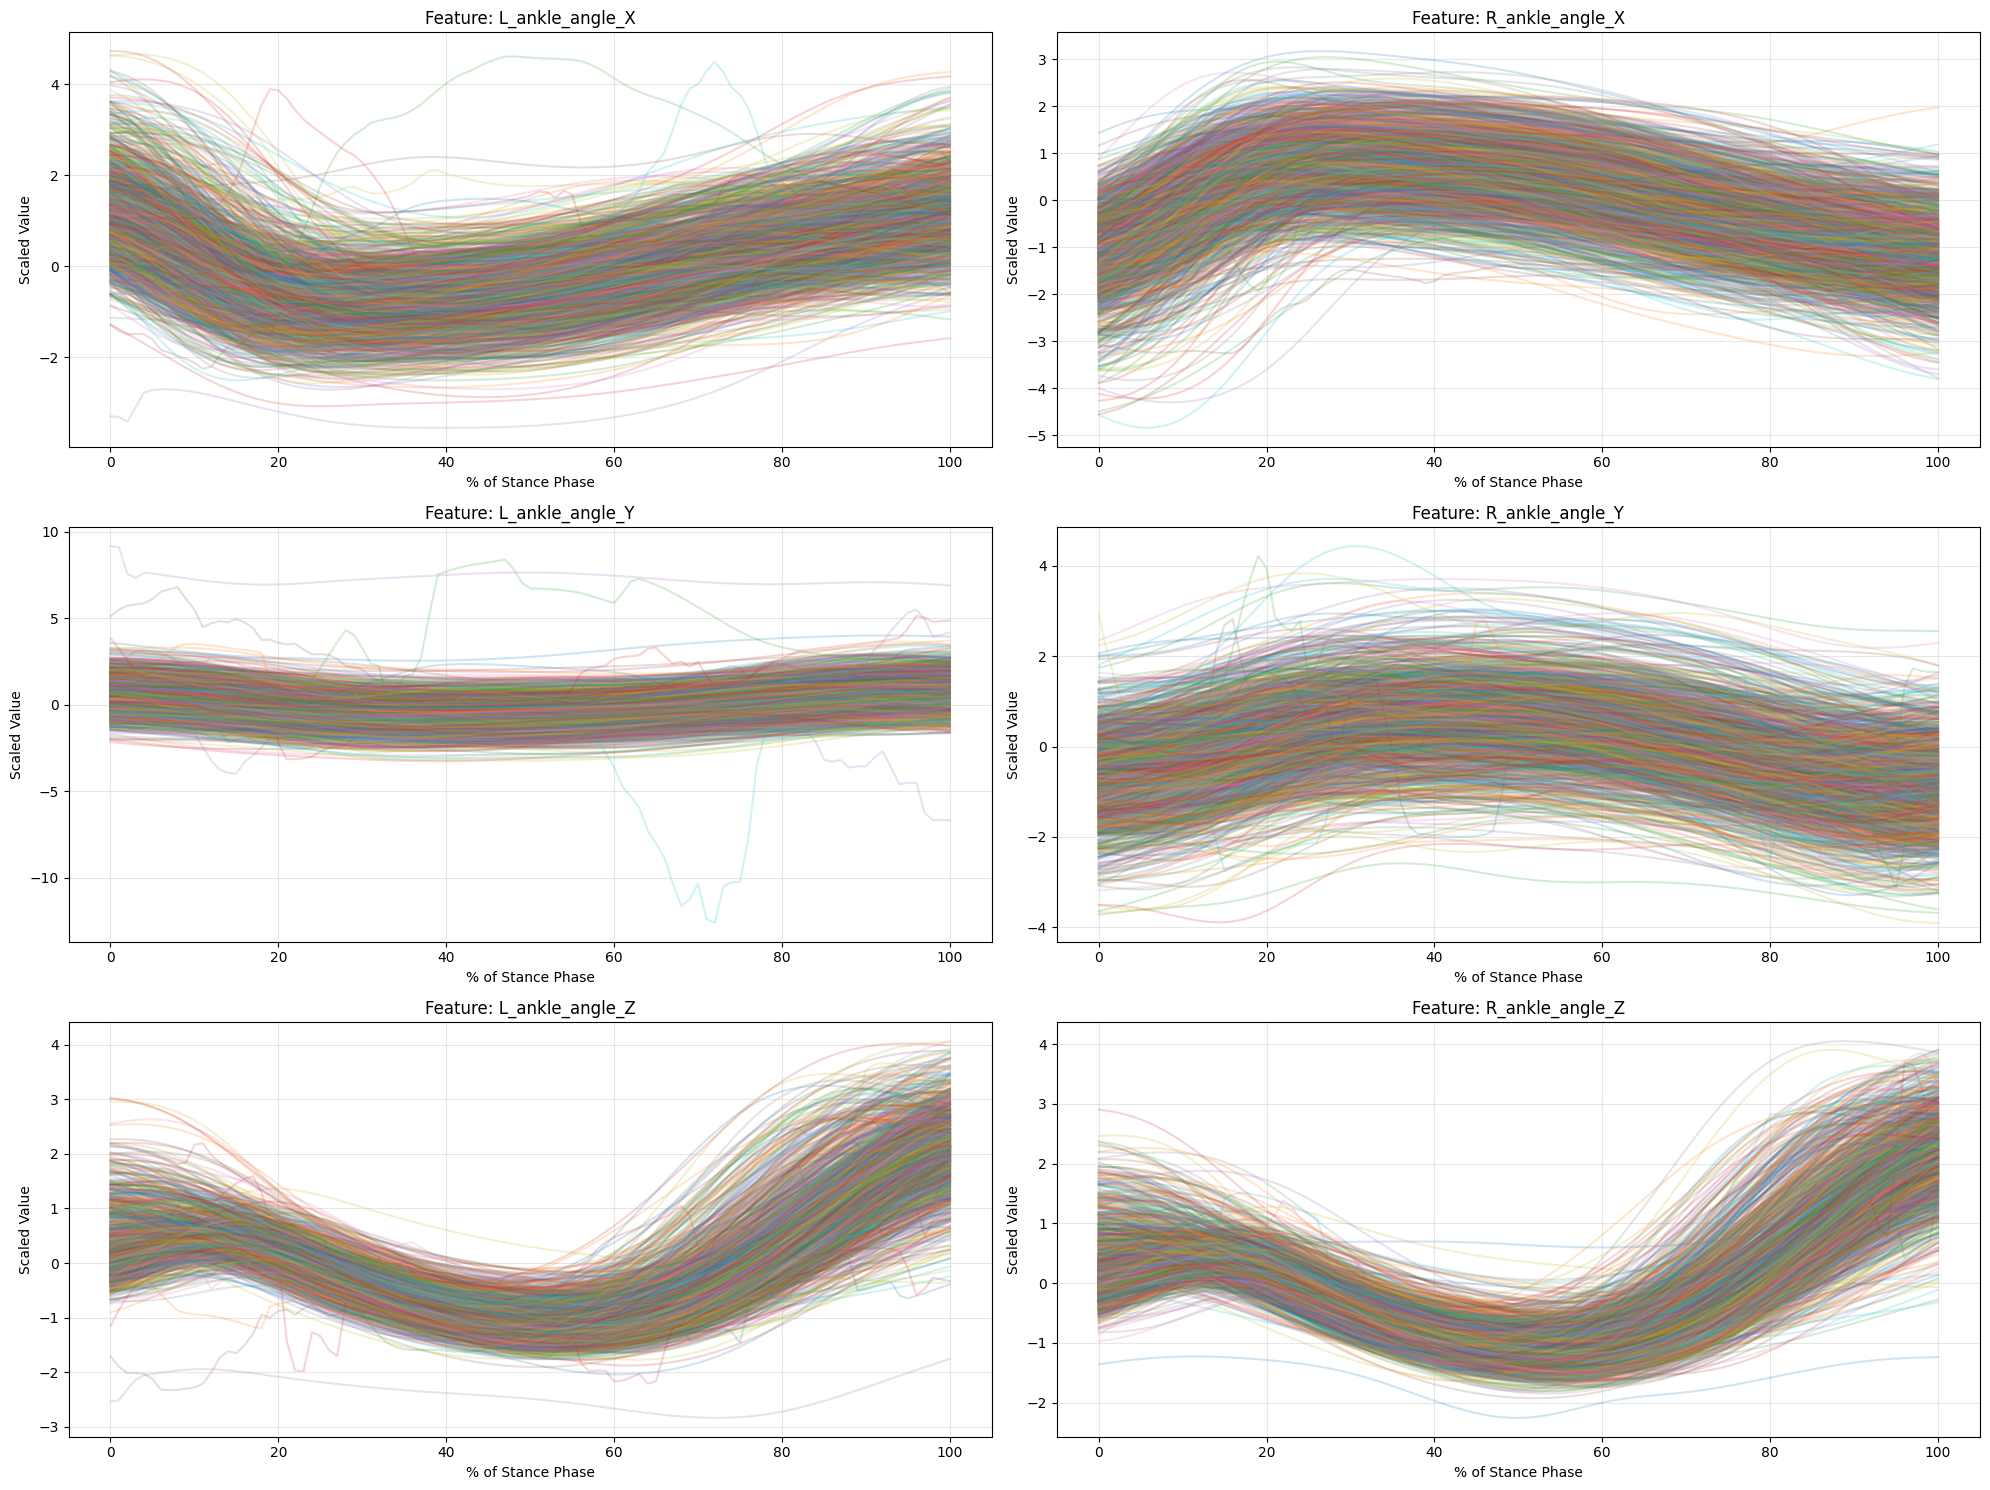

In [13]:
plot_all_features_overlay(
    X_ts=X_ts_scaled,
    channels=channels,
    features=["L_ankle_angle_X", "R_ankle_angle_X", "L_ankle_angle_Y", "R_ankle_angle_Y", "L_ankle_angle_Z", "R_ankle_angle_Z"],
    plots_per_row=2
)


In [14]:
def train_test_group_split(
    X_ts, X_meta, y, subject_id, test_size=0.2, random_state=None
):
    """
    Split data into train and test sets or train and validation sets using GroupShuffleSplit to ensure subject-level separation.
    Returns:
        X_ts_train, X_ts_test, X_meta_train, X_meta_test, y_train, y_test, subject_train, subject_test
    """
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X_ts, y, groups=subject_id))

    # Split the data
    X_ts_train, X_ts_test = X_ts[train_idx], X_ts[test_idx]
    X_meta_train, X_meta_test = X_meta[train_idx], X_meta[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]

    print(f"Training set: {len(train_idx)} sessions from {len(np.unique(subject_train))} subjects")
    print(f"Test/Validation set: {len(test_idx)} sessions from {len(np.unique(subject_test))} subjects")

    # Verify no subject overlap
    subject_overlap = set(subject_train) & set(subject_test)
    if len(subject_overlap) > 0:
        raise ValueError("Subject overlap found in train-test split!!!")

    # Check class distribution in splits
    train_counts = np.bincount(y_train.astype(int))
    test_counts = np.bincount(y_test.astype(int))
    print(f"\nTrain class distribution: {train_counts} ({np.round(train_counts/len(y_train)*100, 2)}%)")
    print(f"Test/Validation class distribution: {test_counts} ({np.round(test_counts/len(y_test)*100, 2)}%)")

    return (
        X_ts_train, X_ts_test,
        X_meta_train, X_meta_test,
        y_train, y_test,
        subject_train, subject_test
    )

print("Train-Test Split")
print("="*50)
(
    X_ts_train, X_ts_test,
    X_meta_train, X_meta_test,
    y_train, y_test,
    subject_train, subject_test
) = train_test_group_split(X_ts_scaled, X_meta_scaled, y, subject_id, test_size=0.2, random_state=RANDOM_STATE)

Train-Test Split
Training set: 1168 sessions from 948 subjects
Test/Validation set: 288 sessions from 237 subjects

Train class distribution: [323 845] ([27.65 72.35]%)
Test/Validation class distribution: [ 74 214] ([25.69 74.31]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_41218/2035436697.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_41218/2035436697.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [15]:
# To handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights")
print("="*50)
print(f"Class weights: {class_weight_dict}")

Class weights
Class weights: {0: np.float64(1.8080495356037152), 1: np.float64(0.6911242603550296)}


In [16]:
print("Train-Validaton Split")
print("="*50)
(
    X_ts_train_final, X_ts_val,
    X_meta_train_final, X_meta_val,
    y_train_final, y_val,
    subject_train_final, subject_val
) = train_test_group_split(X_ts_train, X_meta_train, y_train, subject_train, test_size=0.2, random_state=RANDOM_STATE)

Train-Validaton Split
Training set: 937 sessions from 758 subjects
Test/Validation set: 231 sessions from 190 subjects

Train class distribution: [268 669] ([28.6 71.4]%)
Test/Validation class distribution: [ 55 176] ([23.81 76.19]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_41218/2035436697.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_41218/2035436697.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [17]:
# Save train, test, and validation sets as npz files
if SAVE_DATA:
    print("Saving data to:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "train.npz",
        X_ts=X_ts_train_final,
        X_meta=X_meta_train_final,
        y=y_train_final,
        subject=subject_train_final
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "val.npz",
        X_ts=X_ts_val,
        X_meta=X_meta_val,
        y=y_val,
        subject=subject_val
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "test.npz",
        X_ts=X_ts_test,
        X_meta=X_meta_test,
        y=y_test,
        subject=subject_test
    )

In [18]:
if not SAVE_DATA:
    print("Loading data from:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    train_data = np.load(MODEL_RESULTS_FOLDER / "train.npz")
    val_data   = np.load(MODEL_RESULTS_FOLDER / "val.npz")
    test_data  = np.load(MODEL_RESULTS_FOLDER / "test.npz")

    X_ts_train_final = train_data["X_ts"]
    X_meta_train_final = train_data["X_meta"]
    y_train_final = train_data["y"]
    subject_train_final = train_data["subject"]

    X_ts_val = val_data["X_ts"]
    X_meta_val = val_data["X_meta"]
    y_val = val_data["y"]
    subject_val = val_data["subject"]

    X_ts_test = test_data["X_ts"]
    X_meta_test = test_data["X_meta"]
    y_test = test_data["y"]
    subject_test = test_data["subject"]

print("Train set shapes:")
print("  X_ts_train_final:", X_ts_train_final.shape)
print("  X_meta_train_final:", X_meta_train_final.shape)
print("  y_train_final:", y_train_final.shape)
print("  subject_train_final:", subject_train_final.shape)
print()
print("Validation set shapes:")
print("  X_ts_val:", X_ts_val.shape)
print("  X_meta_val:", X_meta_val.shape)
print("  y_val:", y_val.shape)
print("  subject_val:", subject_val.shape)
print()
print("Test set shapes:")
print("  X_ts_test:", X_ts_test.shape)
print("  X_meta_test:", X_meta_test.shape)
print("  y_test:", y_test.shape)
print("  subject_test:", subject_test.shape)
print()

def class_balance_percent(y):
    counts = np.bincount(y.astype(int))
    total = counts.sum()
    return [f"{100 * c / total:.1f}%" for c in counts]

print("Class balance (train):", class_balance_percent(y_train_final))
print("Class balance (val):", class_balance_percent(y_val))
print("Class balance (test):", class_balance_percent(y_test))

Loading data from:
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm/train.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm/val.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm/test.npz

Train set shapes:
  X_ts_train_final: (937, 101, 48)
  X_meta_train_final: (937, 8)
  y_train_final: (937,)
  subject_train_final: (937,)

Validation set shapes:
  X_ts_val: (231, 101, 48)
  X_meta_val: (231, 8)
  y_val: (231,)
  subject_val: (231,)

Test set shapes:
  X_ts_test: (288, 101, 48)
  X_meta_test: (288, 8)
  y_test: (288,)
  subject_test: (288,)

Class balance (train): ['28.6%', '71.4%']
Class balance (val): ['23.8%', '76.2%']
Class balance (test): ['25.7%', '74.3%']


## Building the model

In [19]:
def build_model(model_name,
                time_steps=101, features=25,
                lstm_units=64, lstm_dropout=0.2,
                head_units=32, head_dropout=0.3,
                lr=1e-3, clipnorm=1.0):
    inp = L.Input(shape=(time_steps, features), name="trial")

    # Assumes inputs are already z-scored.
    x = L.Bidirectional(
            L.LSTM(lstm_units, return_sequences=True, dropout=lstm_dropout),
            name="bilstm_1"
        )(inp)  # (batch, 101, 128)

    avg = L.GlobalAveragePooling1D(name="gap")(x)  # (batch, 128)
    mx  = L.GlobalMaxPooling1D(name="gmp")(x)      # (batch, 128)
    x   = L.Concatenate(name="concat_pool")([avg, mx])  # (batch, 256)

    x = L.Dense(head_units, activation="relu", name="dense_1")(x)
    x = L.Dropout(head_dropout, name="dropout_head")(x)
    out = L.Dense(1, activation="sigmoid", name="prob")(x)

    model = M.Model(inp, out, name=model_name)

    opt = tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=clipnorm)

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR",  name="auc_pr"),
            tf.keras.metrics.AUC(curve="ROC", name="auc_roc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=0.5),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ],
    )
    return model

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max",
                                     patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc_pr", mode="max",
                                         factor=0.5, patience=5, min_lr=1e-6),
    # Save best model
    ModelCheckpoint(
        filepath=str(MODEL_RESULTS_FOLDER / f'best_model.h5'),
        monitor='val_auc_pr',
        save_best_only=True,
        verbose=1
    )
]

## Training of the model

In [21]:
# Split data into unilateral:
X_train_uni, y_train_uni = bilateral_to_unilateral(X_ts_train_final, y_train_final, channels)
print("Train set:")
print("X_train_uni.shape:", X_train_uni.shape)
print("y_train_uni.shape:", y_train_uni.shape)
X_val_uni, y_val_uni = bilateral_to_unilateral(X_ts_val, y_val, channels)
print("\nValidation set:")
print("X_val_uni.shape:", X_val_uni.shape)
print("y_val_uni.shape:", y_val_uni.shape)

Train set:
X_train_uni.shape: (1874, 101, 25)
y_train_uni.shape: (1874,)

Validation set:
X_val_uni.shape: (462, 101, 25)
y_val_uni.shape: (462,)


In [22]:
X_test_uni_left, X_test_uni_right = split_unilateral(X_ts_test, channels)
print("\nTest set:")
print("X_test_uni_left.shape:", X_test_uni_left.shape)
print("X_test_uni_right.shape:", X_test_uni_right.shape)


Test set:
X_test_uni_left.shape: (288, 101, 25)
X_test_uni_right.shape: (288, 101, 25)


In [23]:
BATCH_SIZE = 32

model = build_model(MODEL_NAME)
if SAVE_MODEL:
    history = model.fit(
        X_train_uni, y_train_uni,  # (N,101,25) and (N,)
        validation_data=(X_val_uni, y_val_uni),  # (N,101,25) and (N,)
        epochs=100,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=2,
    )
    print("Training completed!")
else:
    model_path = MODEL_RESULTS_FOLDER / f"best_model.h5"
    model = keras.models.load_model(MODEL_RESULTS_FOLDER / f"best_model.h5")
    print(f"Model loaded from results {model_path}")

Epoch 1/100

Epoch 1: val_auc_pr improved from None to 0.74280, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm/best_model.h5


59/59 - 3s - 45ms/step - accuracy: 0.4803 - auc_pr: 0.7185 - auc_roc: 0.5034 - loss: 0.7113 - precision: 0.7156 - recall: 0.4514 - val_accuracy: 0.4805 - val_auc_pr: 0.7428 - val_auc_roc: 0.4728 - val_loss: 0.6965 - val_precision: 0.7478 - val_recall: 0.4801 - learning_rate: 1.0000e-03
Epoch 2/100

Epoch 2: val_auc_pr improved from 0.74280 to 0.74769, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm/best_model.h5


59/59 - 1s - 22ms/step - accuracy: 0.4904 - auc_pr: 0.7349 - auc_roc: 0.5272 - loss: 0.6995 - precision: 0.7379 - recall: 0.4439 - val_accuracy: 0.4026 - val_auc_pr: 0.7477 - val_auc_roc: 0.4972 - val_loss: 0.7099 - val_precision: 0.7568 - val_recall: 0.3182 - learning_rate: 1.0000e-03
Epoch 3/100

Epoch 3: val_auc_pr did not improve from 0.74769
59/59 - 2s - 27ms/step - accuracy: 0.4973 - auc_pr: 0.7381 - auc_roc: 0.5348 - loss: 0.6992 - precision: 0.7397 - recall: 0.4567 - val_accuracy: 0.4221 - val_auc_pr: 0.7453 - val_auc_roc: 0.4772 - val_loss: 0.7055 - val_precision: 0.7457 - val_recall: 0.3665 - learning_rate: 1.0000e-03
Epoch 4/100

Epoch 4: val_auc_pr improved from 0.74769 to 0.76729, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm/best_model.h5


59/59 - 2s - 31ms/step - accuracy: 0.5117 - auc_pr: 0.7553 - auc_roc: 0.5557 - loss: 0.6960 - precision: 0.7595 - recall: 0.4626 - val_accuracy: 0.4048 - val_auc_pr: 0.7673 - val_auc_roc: 0.4961 - val_loss: 0.7132 - val_precision: 0.7333 - val_recall: 0.3438 - learning_rate: 1.0000e-03
Epoch 5/100

Epoch 5: val_auc_pr improved from 0.76729 to 0.77100, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/unilateral_stance_bilstm/best_model.h5


59/59 - 2s - 30ms/step - accuracy: 0.5037 - auc_pr: 0.7498 - auc_roc: 0.5423 - loss: 0.6955 - precision: 0.7232 - recall: 0.4940 - val_accuracy: 0.5000 - val_auc_pr: 0.7710 - val_auc_roc: 0.5050 - val_loss: 0.6988 - val_precision: 0.7665 - val_recall: 0.4943 - learning_rate: 1.0000e-03
Epoch 6/100

Epoch 6: val_auc_pr did not improve from 0.77100
59/59 - 2s - 31ms/step - accuracy: 0.5203 - auc_pr: 0.7641 - auc_roc: 0.5674 - loss: 0.6926 - precision: 0.7654 - recall: 0.4731 - val_accuracy: 0.4870 - val_auc_pr: 0.7672 - val_auc_roc: 0.5018 - val_loss: 0.6946 - val_precision: 0.7700 - val_recall: 0.4659 - learning_rate: 1.0000e-03
Epoch 7/100

Epoch 7: val_auc_pr did not improve from 0.77100
59/59 - 2s - 30ms/step - accuracy: 0.5326 - auc_pr: 0.7710 - auc_roc: 0.5716 - loss: 0.6908 - precision: 0.7584 - recall: 0.5067 - val_accuracy: 0.4567 - val_auc_pr: 0.7604 - val_auc_roc: 0.4964 - val_loss: 0.7114 - val_precision: 0.7644 - val_recall: 0.4148 - learning_rate: 1.0000e-03
Epoch 8/100

Ep

59/59 - 2s - 29ms/step - accuracy: 0.5459 - auc_pr: 0.7704 - auc_roc: 0.5803 - loss: 0.6908 - precision: 0.7508 - recall: 0.5448 - val_accuracy: 0.4372 - val_auc_pr: 0.7754 - val_auc_roc: 0.5106 - val_loss: 0.7200 - val_precision: 0.7805 - val_recall: 0.3636 - learning_rate: 1.0000e-03
Epoch 9/100

Epoch 9: val_auc_pr did not improve from 0.77542
59/59 - 2s - 31ms/step - accuracy: 0.5571 - auc_pr: 0.7858 - auc_roc: 0.6093 - loss: 0.6839 - precision: 0.7829 - recall: 0.5254 - val_accuracy: 0.4502 - val_auc_pr: 0.7677 - val_auc_roc: 0.5061 - val_loss: 0.7187 - val_precision: 0.7606 - val_recall: 0.4062 - learning_rate: 1.0000e-03
Epoch 10/100

Epoch 10: val_auc_pr did not improve from 0.77542
59/59 - 2s - 28ms/step - accuracy: 0.5795 - auc_pr: 0.7934 - auc_roc: 0.6078 - loss: 0.6794 - precision: 0.7696 - recall: 0.5867 - val_accuracy: 0.4610 - val_auc_pr: 0.7587 - val_auc_roc: 0.5001 - val_loss: 0.7324 - val_precision: 0.7614 - val_recall: 0.4261 - learning_rate: 1.0000e-03
Epoch 11/100


## Evaluation of the model:

In [25]:
def plot_confusion_matrix(y_true, y_pred, labels):
    plt.figure()
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_true, 
        y_pred, 
        display_labels=labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {MODEL_NAME}')

def plot_roc_curve(y_true, y_pred_proba):
    plt.figure()
    ax = plt.gca()
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

    roc_disp = RocCurveDisplay.from_predictions(
        y_true, 
        y_pred_proba, 
        name=MODEL_NAME,
        ax=ax,
    )
    roc_disp.ax_.set_title('ROC Curve')

def plot_precision_recall_curve(y_true, y_pred_proba):
    """Plot precision-recall curve."""
    plt.figure()
    pr_disp = PrecisionRecallDisplay.from_predictions(
        y_true,
        y_pred_proba,
        name=MODEL_NAME
    )
    pr_disp.ax_.set_title('Precision-Recall Curve')


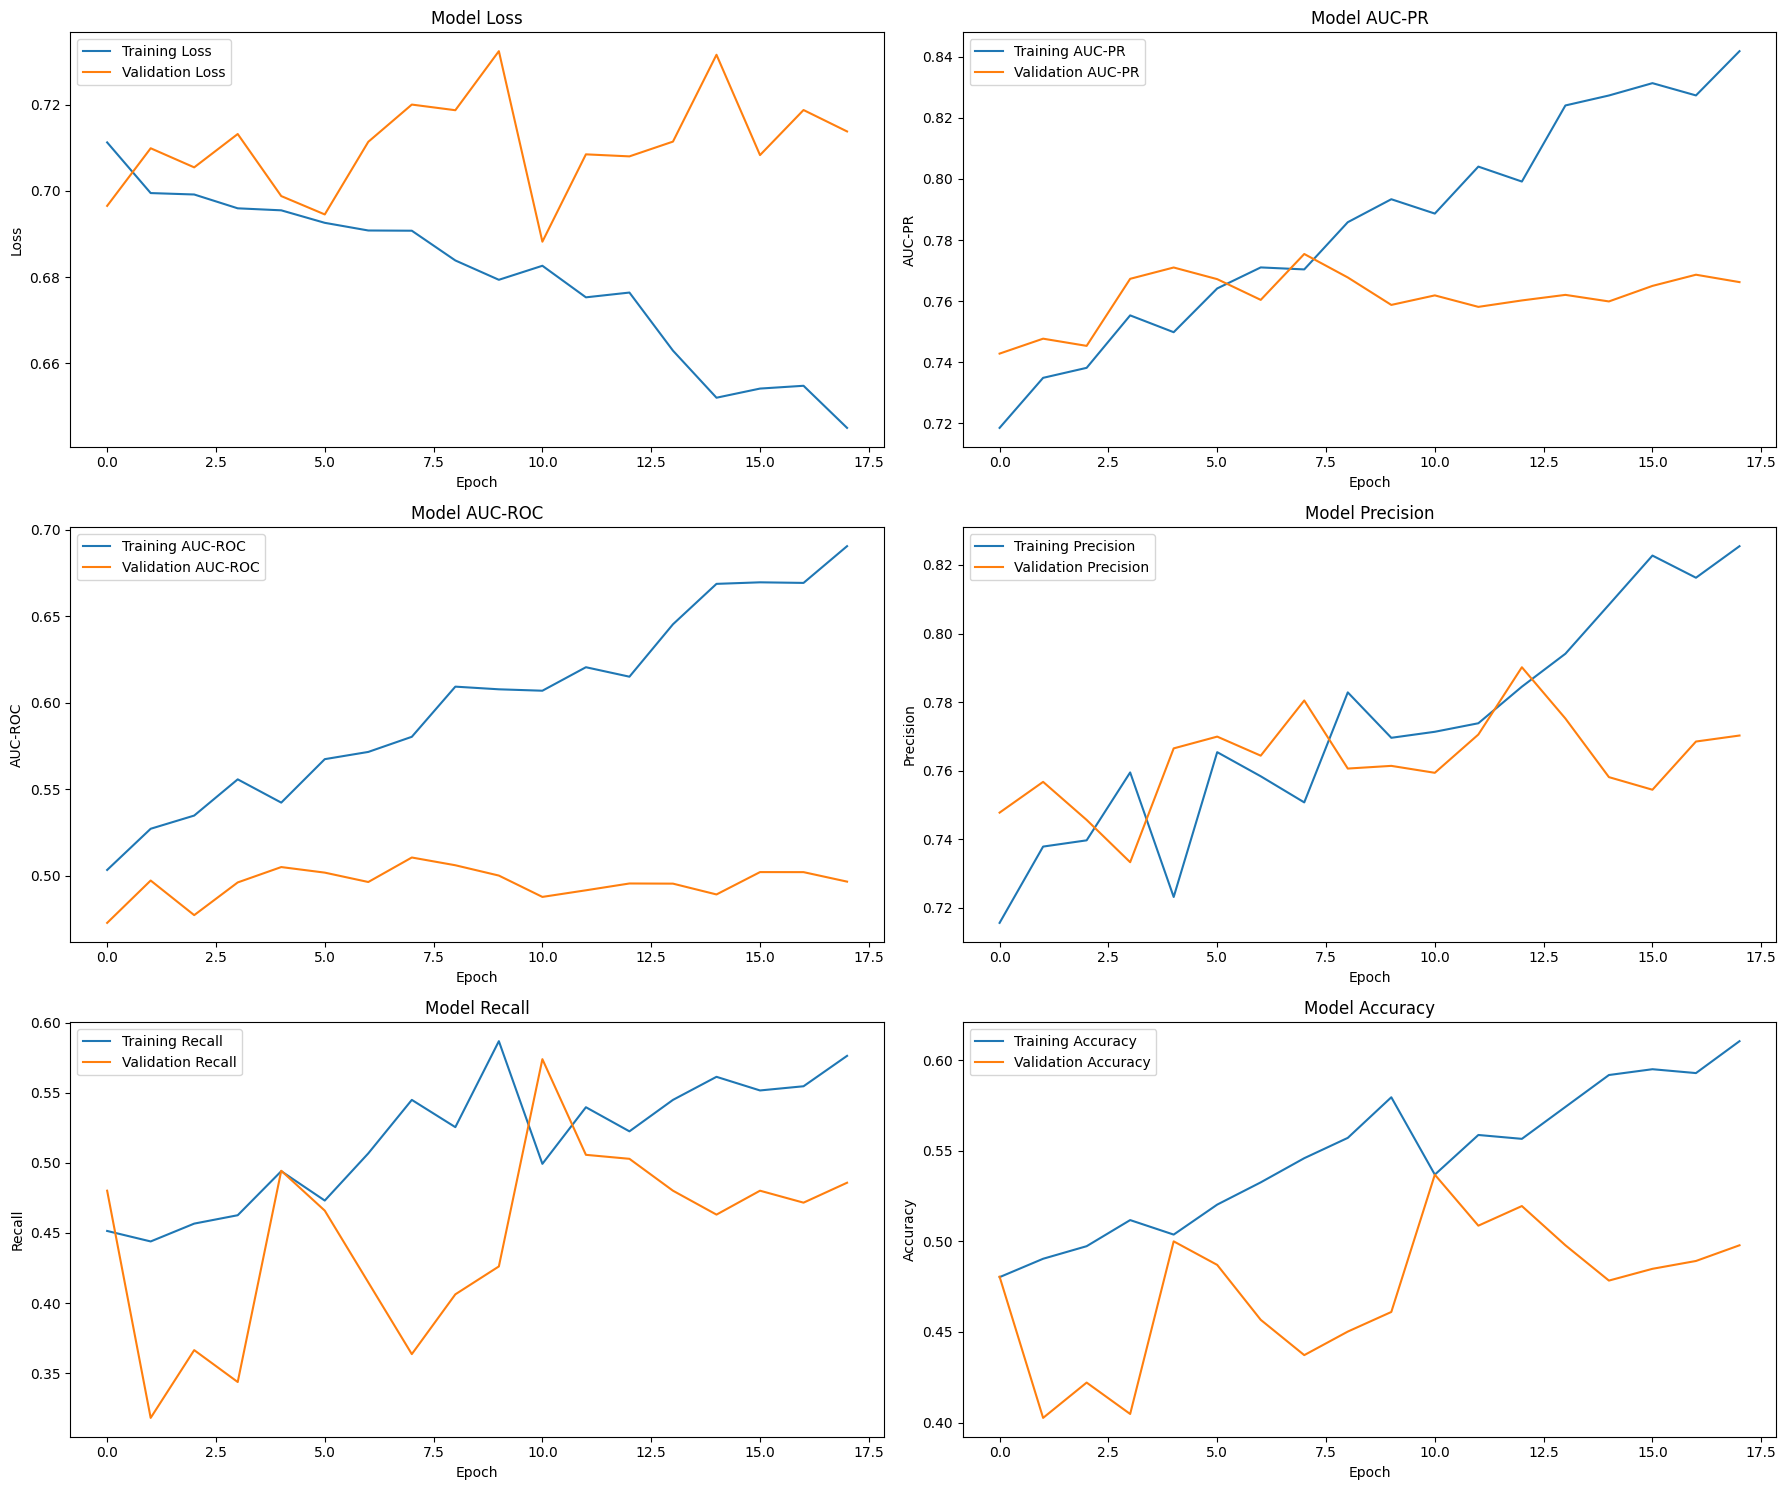

<Figure size 640x480 with 0 Axes>

In [26]:
# Step 10: Plot Training History
import matplotlib.pyplot as plt

# The issue: You have a 4x2 grid, but only plot on axes[3,0] in the last row.
# axes[3,1] is always empty, so it shows as a blank/malformed subplot.
# Solution: Hide axes[3,1] explicitly.

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

if 'auc_pr' in history.history and 'val_auc_pr' in history.history:
    axes[0, 1].plot(history.history['auc_pr'], label='Training AUC-PR')
    axes[0, 1].plot(history.history['val_auc_pr'], label='Validation AUC-PR')
    axes[0, 1].set_title('Model AUC-PR')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC-PR')
    axes[0, 1].legend()
else:
    axes[0, 1].set_visible(False)

if 'auc_roc' in history.history and 'val_auc_roc' in history.history:
    axes[1, 0].plot(history.history['auc_roc'], label='Training AUC-ROC')
    axes[1, 0].plot(history.history['val_auc_roc'], label='Validation AUC-ROC')
    axes[1, 0].set_title('Model AUC-ROC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC-ROC')
    axes[1, 0].legend()
else:
    axes[1, 0].set_visible(False)

if 'precision' in history.history and 'val_precision' in history.history:
    axes[1, 1].plot(history.history['precision'], label='Training Precision')
    axes[1, 1].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 1].set_title('Model Precision')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
else:
    axes[1, 1].set_visible(False)

if 'recall' in history.history and 'val_recall' in history.history:
    axes[2, 0].plot(history.history['recall'], label='Training Recall')
    axes[2, 0].plot(history.history['val_recall'], label='Validation Recall')
    axes[2, 0].set_title('Model Recall')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Recall')
    axes[2, 0].legend()
else:
    axes[2, 0].set_visible(False)

if 'accuracy' in history.history and 'val_accuracy' in history.history:
    axes[2, 1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[2, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[2, 1].set_title('Model Accuracy')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].legend()
else:
    axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Save the main plot
plt.savefig(MODEL_RESULTS_FOLDER / f'training_history.png', dpi=300, bbox_inches='tight')

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MODEL EVALUATION RESULTS
=== Bilateral metrics - Sklearn ===
Test AUC-PR : 0.7163
Test Accuracy: 0.3403
Test F1 Score: 0.7163
=== Left side metrics ===
Test AUC-ROC (Model): 0.4680
Test AUC-PR (Model): 0.7111
Test Accuracy on left side: 0.3160
Test Precision on left side: 0.6308
Test Recall on left side: 0.1916
=== Right side metrics ===
Test AUC-ROC (Model): 0.5019
Test AUC-PR (Model): 0.7462
Test Accuracy on right side: 0.4549
Test Precision on right side: 0.7568
Test Recall on right side: 0.3925

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Not Injured       0.23      0.66      0.34        74
     Injured       0.66      0.23      0.34       214

    accuracy                           0.34       288
   macro avg       0.45      0.45      0.34       288
weighted avg       0.55      0.34      0.34       288



<Figure size 640x480 with 0 Axes>

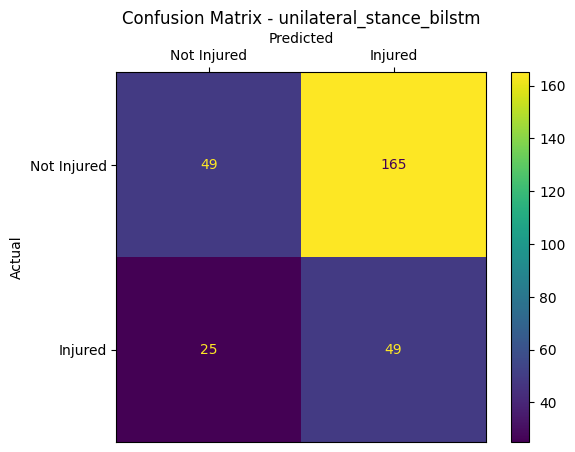

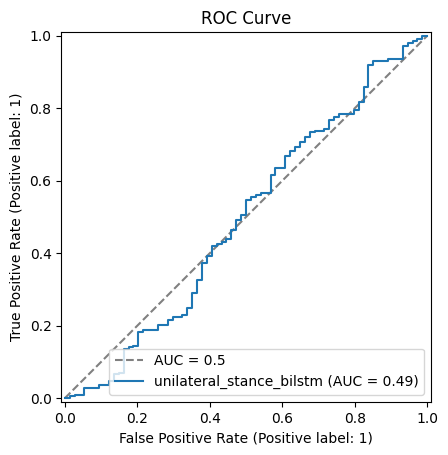

<Figure size 640x480 with 0 Axes>

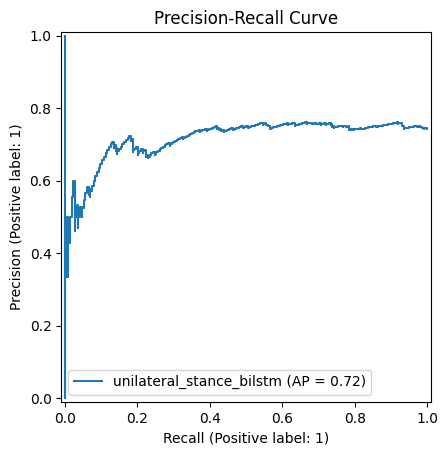

In [27]:
# Make predictions on test set using unilateral data
# Since we are turning into unilateral a bilateral dataset, we should predict both side individually,
#  then combine them.
# Options are: We can use either the mean or the max of the two sides.
y_pred_proba_left = model.predict(X_test_uni_left)
y_pred_proba_right = model.predict(X_test_uni_right)
y_pred_proba = 0.5 * (y_pred_proba_left + y_pred_proba_right) # Should I use the max?

THRESHOLD = 0.5
y_pred = (y_pred_proba > THRESHOLD).astype(int).flatten()


tf.keras.metrics.AUC(curve="PR",  name="auc_pr"),
tf.keras.metrics.AUC(curve="ROC", name="auc_roc"),
tf.keras.metrics.F1Score(name="f1_score"),
tf.keras.metrics.Accuracy(name="accuracy"),
tf.keras.metrics.Precision(name="precision"),
tf.keras.metrics.Recall(name="recall")

# Calculate metrics - model returns: loss, auc_pr, auc_roc, precision, recall
# Since we have an unilateral model, we can evaluate both sides individually.
# NOTE: y is the same for both sides.
results_by_side = {}
sides = ("left", "right")
for side, X, y in zip(sides, (X_test_uni_left, X_test_uni_right), (y_test, y_test)):
    test_loss, test_auc_pr, test_auc_roc, test_accuracy, test_precision, test_recall = model.evaluate(
        X, y, verbose=0
    )
    results_by_side[side] = {
        "loss": test_loss,
        "auc_pr": test_auc_pr,
        "auc_roc": test_auc_roc,
        "accuracy": test_accuracy,
        "precision": test_precision,
        "recall": test_recall
    }

test_sklearn_accuracy = accuracy_score(y_test, y_pred)
test_sklearn_f1 = f1_score(y_test, y_pred)
test_sklearn_avg_precision = average_precision_score(y_test, y_pred_proba, average="weighted")

print("MODEL EVALUATION RESULTS")
print("="*50)
print("=== Bilateral metrics - Sklearn ===")
print(f"Test AUC-PR : {test_sklearn_avg_precision:.4f}")
print(f"Test Accuracy: {test_sklearn_accuracy:.4f}")
print(f"Test F1 Score: {test_sklearn_avg_precision:.4f}")


for side, result in results_by_side.items():
    print("="*50)
    print(f"=== {side.capitalize()} side metrics ===")
    print("="*50)
    print(f"Test AUC-ROC (Model): {result['auc_roc']:.4f}")
    print(f"Test AUC-PR (Model): {result['auc_pr']:.4f}")
    print(f"Test Accuracy on {side} side: {result['accuracy']:.4f}")
    print(f"Test Precision on {side} side: {result['precision']:.4f}")
    print(f"Test Recall on {side} side: {result['recall']:.4f}")
    

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Not Injured', 'Injured']))

plot_confusion_matrix(y_test, y_pred, labels=['Not Injured', 'Injured'])
plot_roc_curve(y_test, y_pred_proba)
plot_precision_recall_curve(y_test, y_pred_proba)

plt.show()

In [30]:
# Save the trained model
if SAVE_MODEL:
    model.save(MODEL_RESULTS_FOLDER / f'final_model.h5')

    # Save scalers for future use
    with open(MODEL_RESULTS_FOLDER / f'scalers.pkl', 'wb') as f:
        pickle.dump({
            'timeseries_scaler': scaler_ts,
            'metadata_scaler': scaler_meta
        }, f)

    # Save training results
    results = {
        'test_accuracy': float(test_sklearn_accuracy),
        'test_f1': float(test_sklearn_f1),
        'tes_avg_precision': float(test_sklearn_avg_precision),
        'results_by_side': results_by_side,
        'model_name': MODEL_NAME,
        'training_params': {
            "epochs": model.history.params['epochs'],
            'epochs_run': len(model.history.epoch),
            'loss': model.history.history['loss'],
            'batch_size': BATCH_SIZE,
            'learning_rate': float(model.optimizer.learning_rate.numpy()),
            'dropout_rate': next((layer.rate for layer in model.layers if hasattr(layer, 'rate')), "N/A"),
            'class_weights': class_weight_dict
        }
    }

    with open(MODEL_RESULTS_FOLDER / f'results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print(f"Model and results saved!")



Model and results saved!
